In [3]:
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
import matplotlib.pyplot as plt
import numpy as np

# Load Dataset
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

print("Training Images :", x_train.shape)
print("Testing Images  :", x_test.shape)

Training Images : (60000, 28, 28)
Testing Images  : (10000, 28, 28)


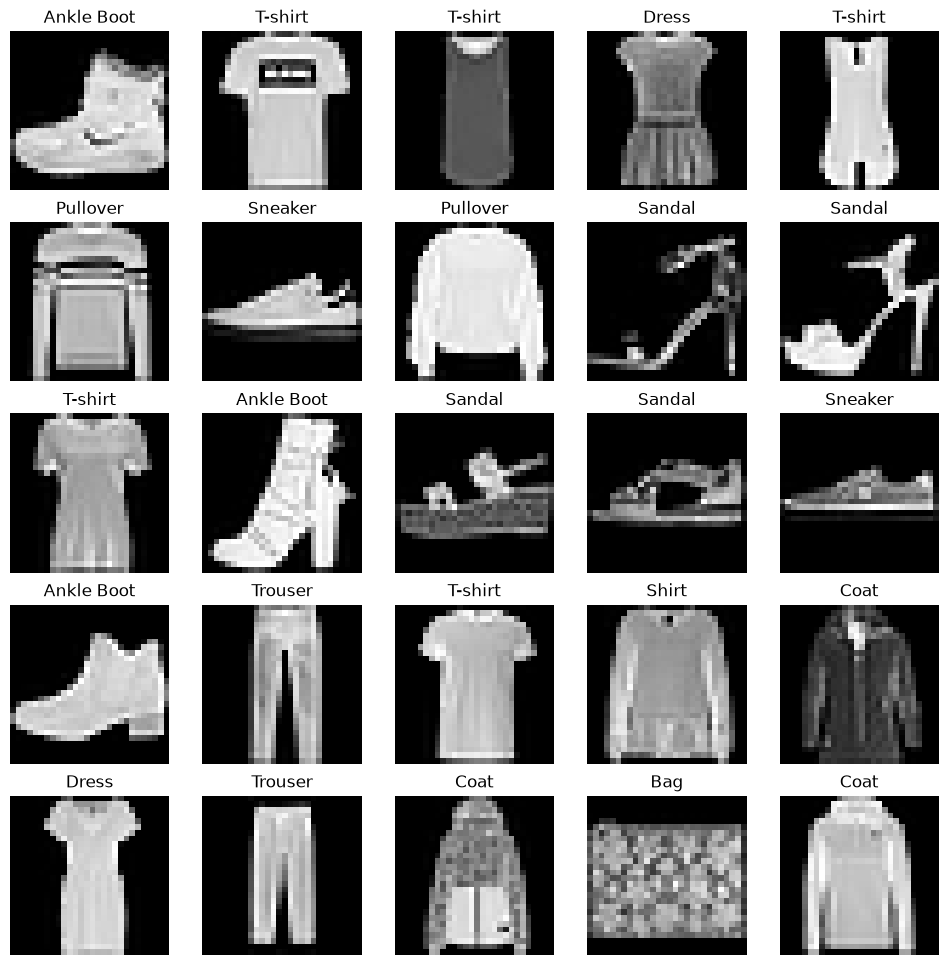

In [4]:
class_names = [
    'T-shirt',
    'Trouser',
    'Pullover',
    'Dress',
    'Coat',
    'Sandal',
    'Shirt',
    'Sneaker',
    'Bag',
    'Ankle Boot'
]

plt.figure(figsize=(12,12))

for i in range(25):
    plt.subplot(5,5,i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(class_names[y_train[i]])
    plt.axis('off')

plt.show()

In [5]:
print("Minimum Pixel :", x_train.min())
print("Maximum Pixel :", x_train.max())

print("Training Labels :", np.unique(y_train))

Minimum Pixel : 0
Maximum Pixel : 255
Training Labels : [0 1 2 3 4 5 6 7 8 9]


In [6]:
x_train = x_train / 255.0
x_test = x_test / 255.0

print(x_train[0].min(), x_train[0].max())

0.0 1.0


In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

In [8]:
x_train = x_train.reshape(-1,28,28,1)
x_test = x_test.reshape(-1,28,28,1)

print(x_train.shape)
print(x_test.shape)

(60000, 28, 28, 1)
(10000, 28, 28, 1)


In [9]:
model = Sequential()


# First convolution layer
model.add(
    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(28,28,1)
    )
)


# Pooling
model.add(
    MaxPooling2D((2,2))
)


# Second convolution layer
model.add(
    Conv2D(
        64,
        (3,3),
        activation='relu'
    )
)


model.add(
    MaxPooling2D((2,2))
)


# Convert feature maps into vector
model.add(
    Flatten()
)


# Fully connected layer
model.add(
    Dense(
        128,
        activation='relu'
    )
)


# Prevent overfitting
model.add(
    Dropout(0.3)
)


# Output layer
model.add(
    Dense(
        10,
        activation='softmax'
    )
)

c:\Users\Aditi.m\smart-retail-ai\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [10]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [12]:
history = model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 25s 29ms/step - accuracy: 0.7831 - loss: 0.6010 - val_accuracy: 0.8532 - val_loss: 0.4084
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 20s 27ms/step - accuracy: 0.8604 - loss: 0.3848 - val_accuracy: 0.8808 - val_loss: 0.3293
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 20s 27ms/step - accuracy: 0.8772 - loss: 0.3366 - val_accuracy: 0.8868 - val_loss: 0.3082
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 20s 27ms/step - accuracy: 0.8892 - loss: 0.3052 - val_accuracy: 0.8973 - val_loss: 0.2820
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 20s 26ms/step - accuracy: 0.8962 - loss: 0.2843 - val_accuracy: 0.8959 - val_loss: 0.2816
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 20s 27ms/step - accuracy: 0.9052 - loss: 0.2607 - val_accuracy: 0.9045 - val_loss: 0.2658
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 26s 35ms/step - accuracy: 0.9088 - loss: 0.2463 - val_accuracy: 0.9059 - val_loss: 0.2612
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 38s 31ms/step - accuracy: 0.9159 - loss: 0.2263 - 

In [13]:
test_loss, test_accuracy = model.evaluate(
    x_test,
    y_test
)

print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9065 - loss: 0.2653
Test Accuracy: 0.906499981880188


In [14]:
model.save(
    "../app/models/product_classifier.h5"
)

In [15]:
import sys
print(sys.executable)


c:\Users\Aditi.m\smart-retail-ai\venv\Scripts\python.exe


In [16]:
from tensorflow.keras.models import load_model

model = load_model("../app/models/product_classifier.h5")

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,036 (879.05 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [17]:
print("Input Shape :", model.input_shape)
print("Output Shape:", model.output_shape)

Input Shape : (None, 28, 28, 1)
Output Shape: (None, 10)


In [20]:
import matplotlib.pyplot as plt

plt.imsave(
    "../uploads/test_image.png",
    x_test[0].squeeze(),
    cmap="gray"
)

print("Image saved successfully!")
print("Actual Label:", class_names[y_test[0]])

Image saved successfully!
Actual Label: Ankle Boot


In [19]:
print(x_test[0].shape)


(28, 28, 1)
